# What is Plotnine?


* Plotnine is a a data visualization package for Matplotlib that uses the "Grammar of Graphics."
* This is the same type of encoding grammar used most commonly in ggplot2 in R, but also in Tableau, Plotly, as well as the Python packages seaborn, bokeh, altair, and Plotnine!


  


* Plotnine allows users who are most familiar with ggplot2 in R, but also other uses of Grammar of Graphics, to make plots in Matplotlib quickly!

## What is Grammar of Graphics?
* Grammar of Graphics is a structural framework used to create data visualizations.
* It was developped in 1999 by statistician Leland Wilkinson to simplify plots into their four key layered aspects.



  


### Grammar of Graphics breaks every data visualization down into four layered parts:
* The data and how the data should show up visually (aesthetic mapping).
* Statistical transformations such as binning or aggregating if needed.
* The geometry used to encode the visualization or what sort of object is being shown (point, line, polygon, etc).
* Position adjustedment if needed.

* Using Grammar of Graphics you can easily change between plot types without by just changing the geometry without having to change any other part of the code!

# How to Install Plotnine

Tutorial for installing Plotnine: https://plotnine.org/guide/overview.html

#### Note: you must have uv installed for this tutorial

# Step 1
## Activate your virtual environment

### For Mac, open Terminal and type and run
source (virtual environment name)/bin/activate

For example:
source archyviz/bin/activate

### For PC, in Command Prompt type and run

(virtual environment folder name)\Scripts\activate

For example: archyviz\Scripts\activate

# Step 2

## Get Plotnine

### In Terminal or Command Prompt type and run
uv pip install plotnine

# Step 3

### Import Plotnine in your Jupyter Lab notebook


In [1]:
from plotnine import *
#* tells matplotlib to import all public objects from plotnine

### Parts of ggplot
You can use ggplot to plot in matplot lib very similar to in R!

# Starter ggplot Parameters
- `data` - This can be a defined variable or an array.
- `aes()` - This is the aesthetic mapping. It will label the x and y axises.
- `geom_*()` - Specifies what sort of geometry to add to a plot. geom_point creates a scatter plot. You can change it to a line by changing the paramenter to geom_smooth() or add a trend line by adding this as an additional parameter.
- `scale_*()` - Scale sets the names on things like legends, guides, axes, and color bands. They also can customize how the data visualized with the aes line appear.


## Starting Plotting with Plotnine

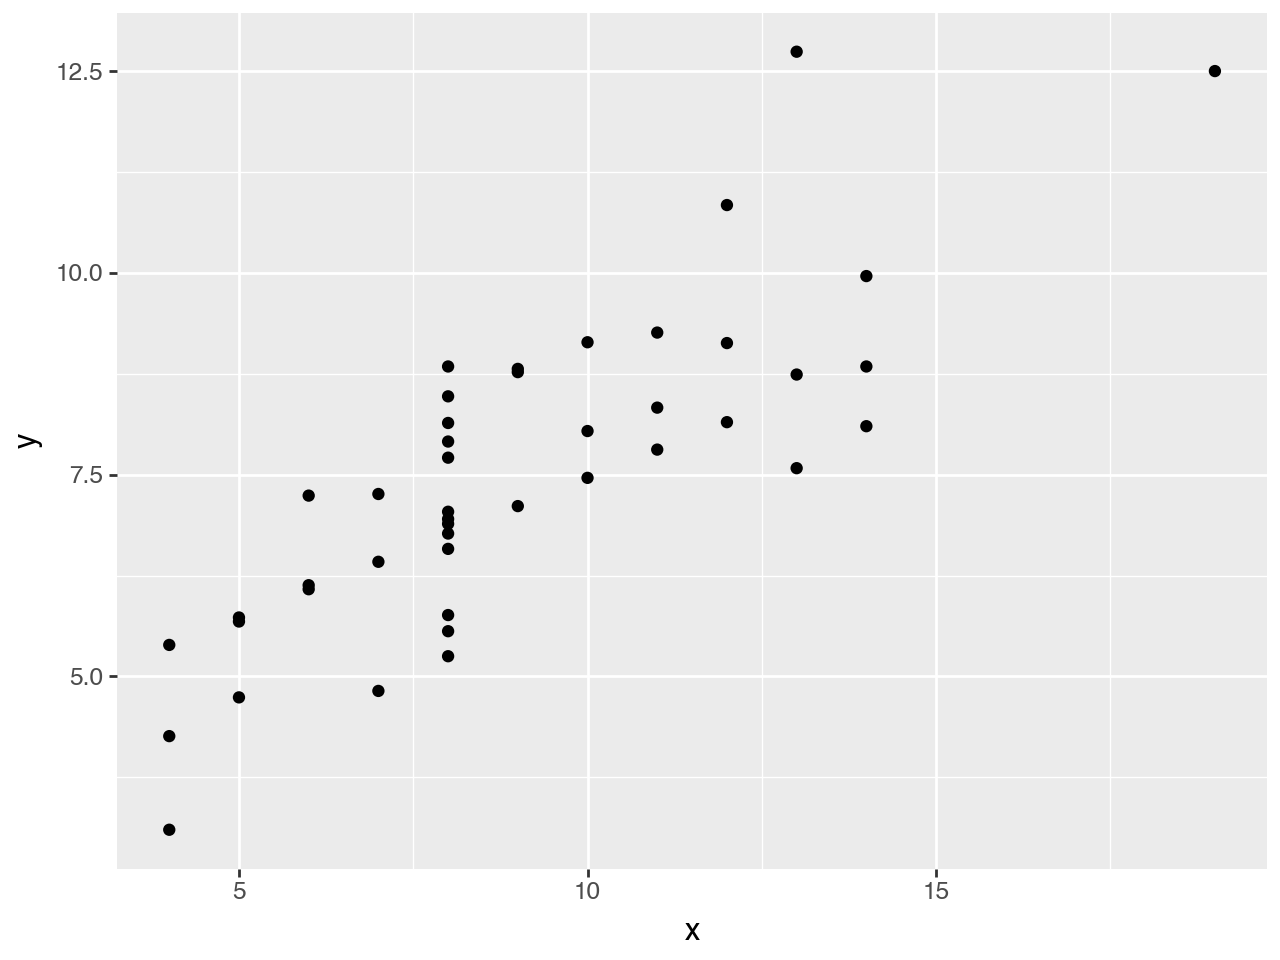

In [2]:
import matplotlib.pyplot as plt
import numpy as np
# Set random seed for reproducibility

from plotnine.data import anscombe_quartet 
#for artist in ax.get_children(): print(type(artist))



p=(
    ggplot(anscombe_quartet, aes(x="x", y="y")) #here we are give it what variables are x and y
    + geom_point()
    )

(p)

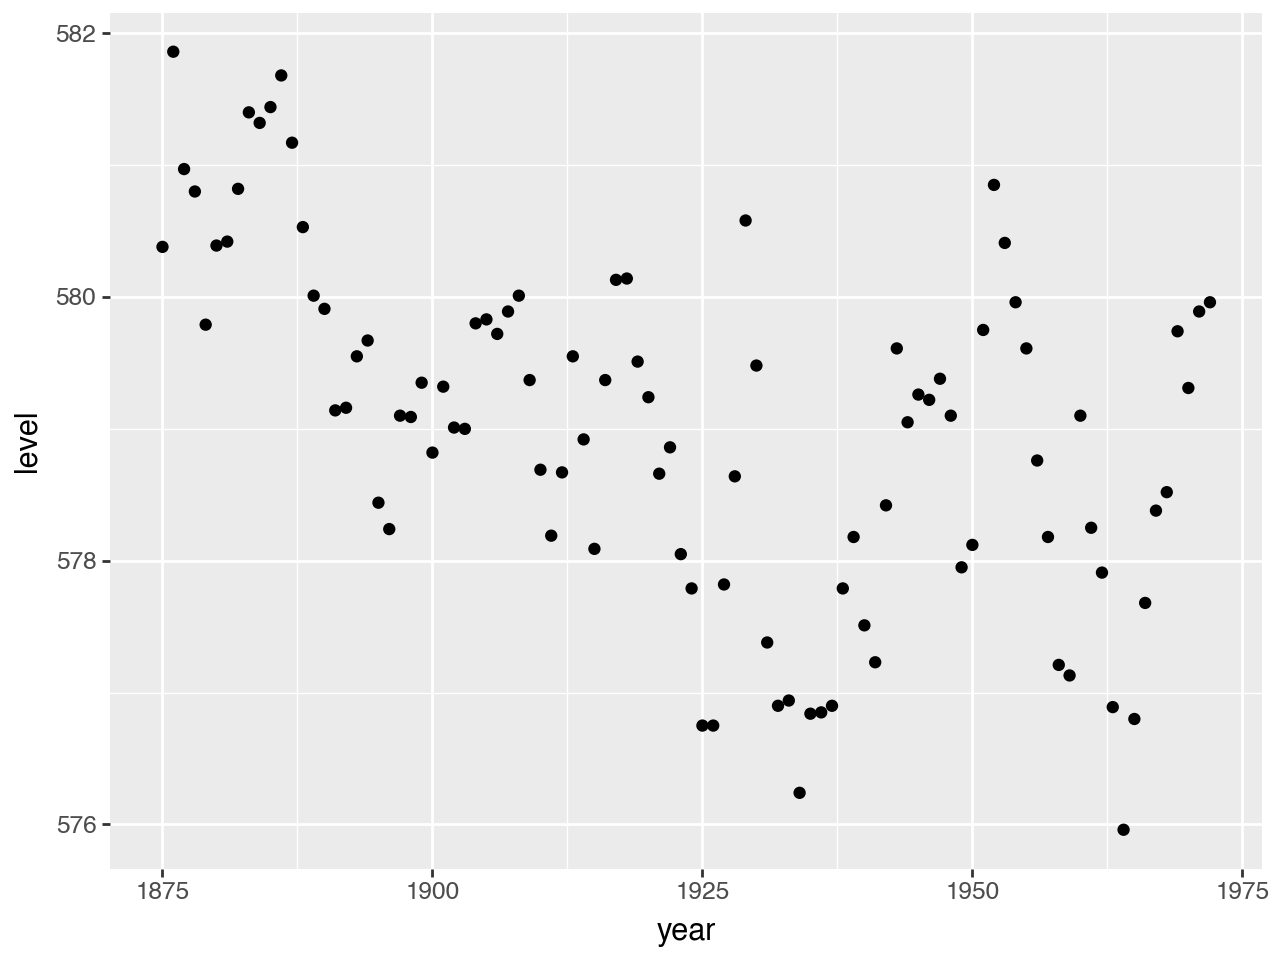

In [4]:
#in aes we indicate what columns of the data we want to plot. For levens in Lauke Huron our options are:
#level (Level in feet), year (numerical year from 1870-1972), and decade (decades from 1870-1972, ex. 1870, 1880, etc)

from plotnine.data import huron
p=(
    ggplot(huron, aes(x="year", y='level'))
    +geom_point()
    )

(p)

/Users/evijonas/python/archyviz/lib/python3.14/site-packages/plotnine/stats/smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


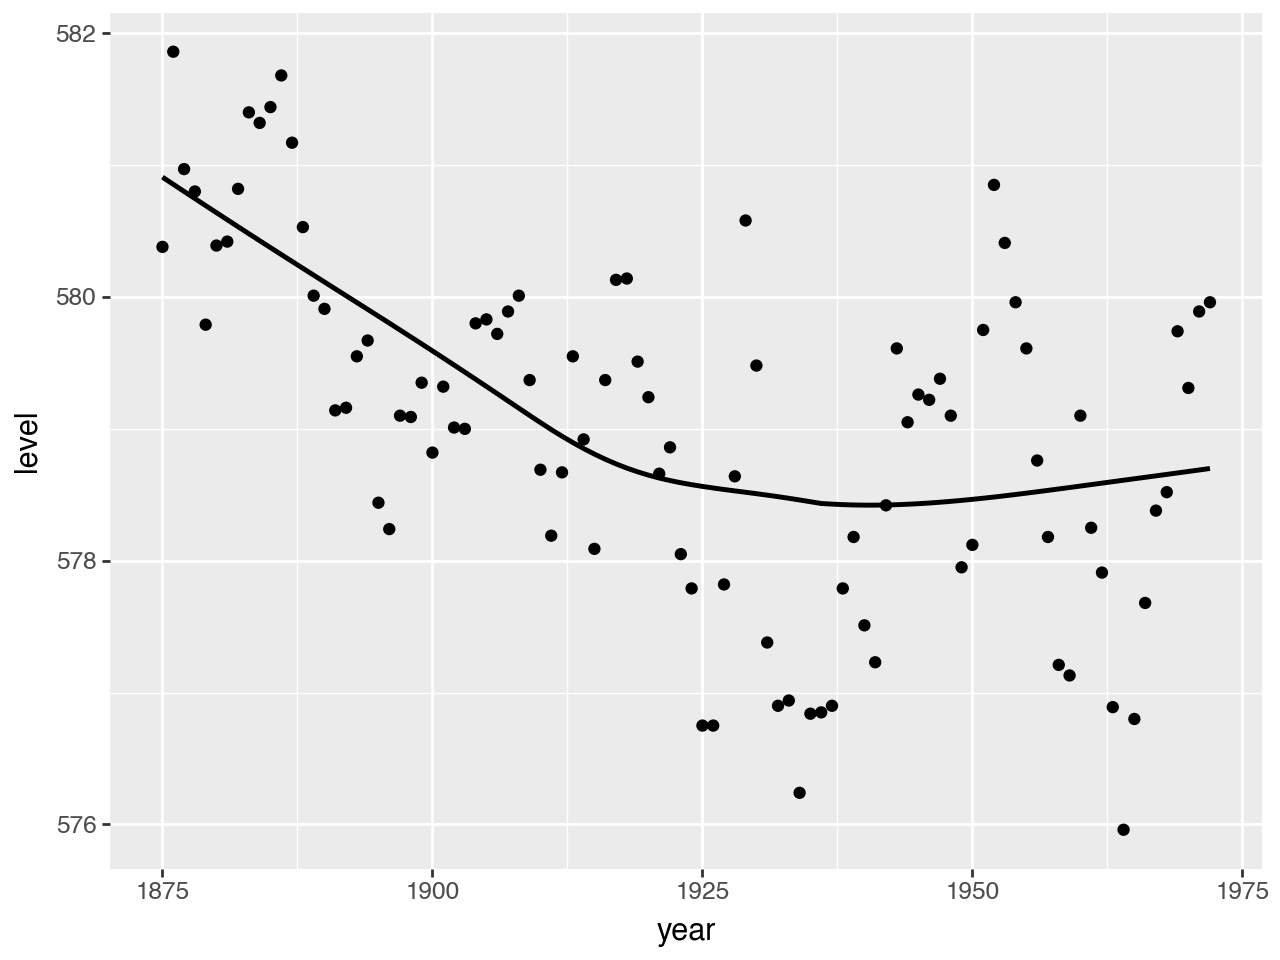

In [5]:
#you can add geoms on top of eachother to fit a line to your data. 
#this defaults to a loess smooth curve

p=(
    ggplot(huron, aes("year", "level"))
    + geom_point()
    + geom_smooth()
    )

(p)

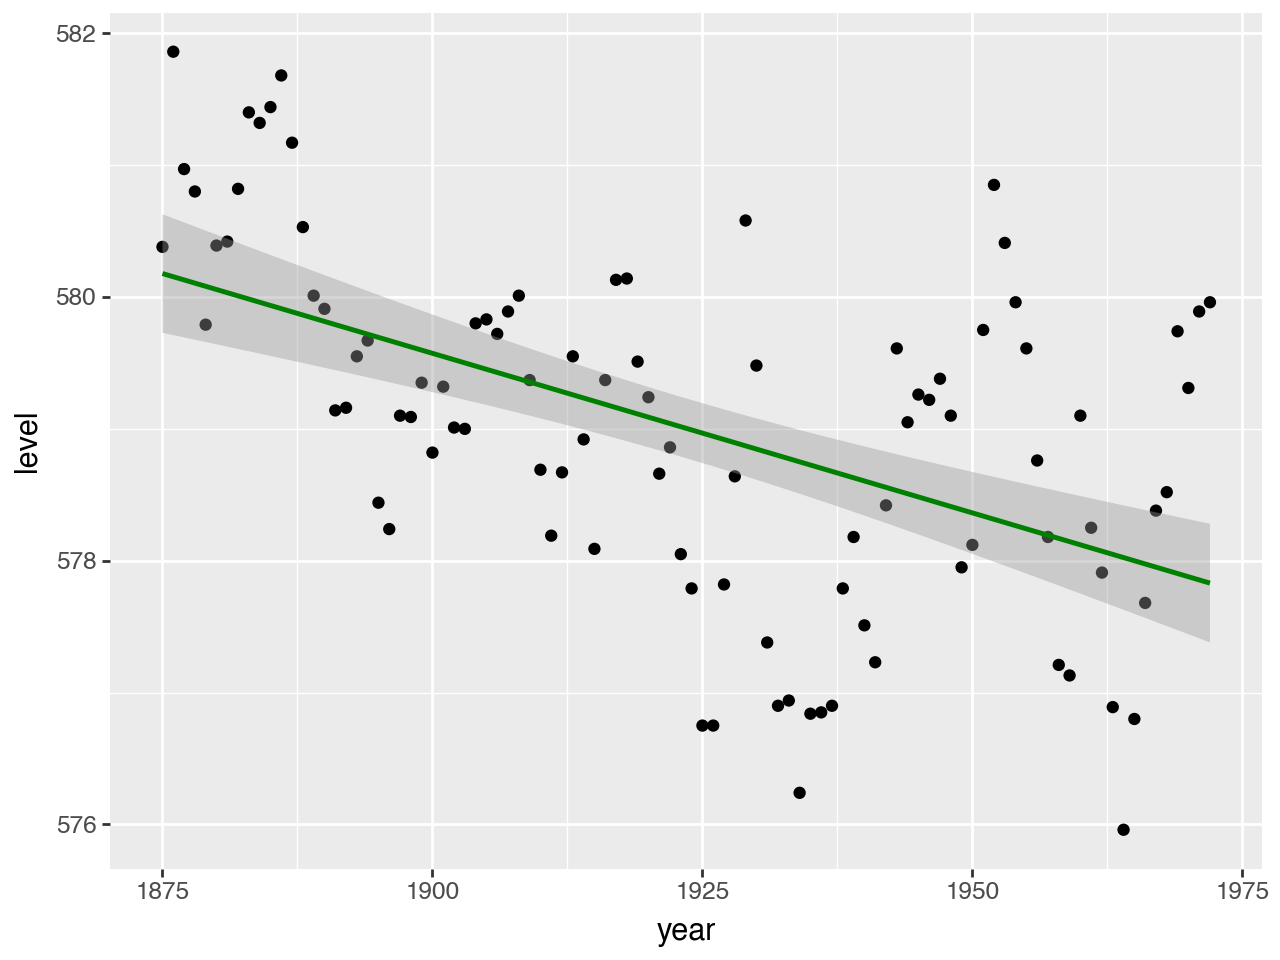

In [6]:
#you can even give geom parameters such as method to fit a linear line to the data and change the geom color

p=(
    ggplot(huron, aes("year", "level"))
    + geom_point()
    + geom_smooth(method='lm', color='green')
)


(p)

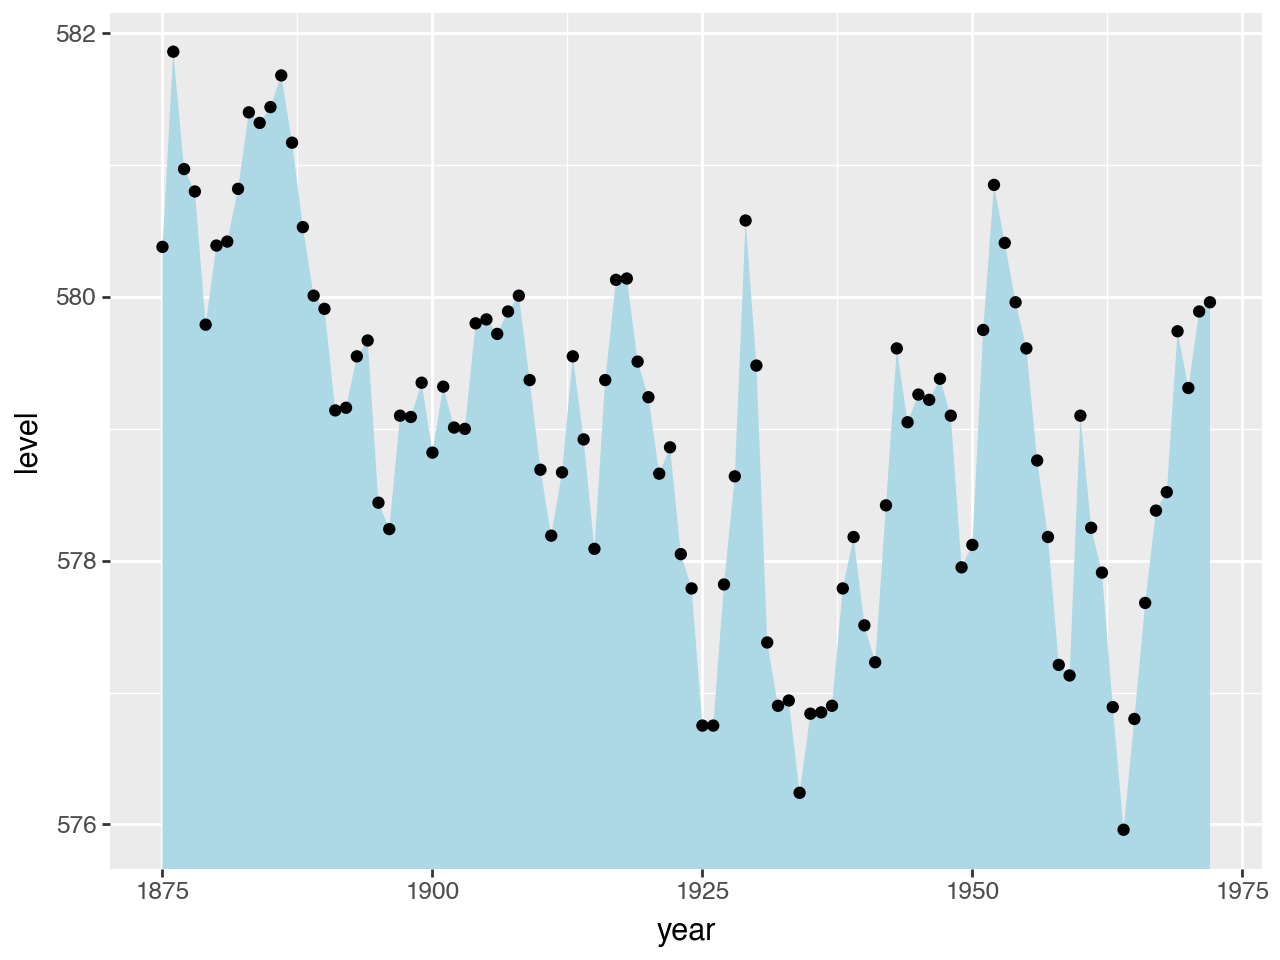

In [9]:
#you can change the geom which changes the chart type

p=(
    ggplot(huron, aes("year", "level"))
    + geom_ribbon(aes(ymax='level'), ymin='0', fill='lightblue') #fills in below a line
    + geom_point()
)
(p)

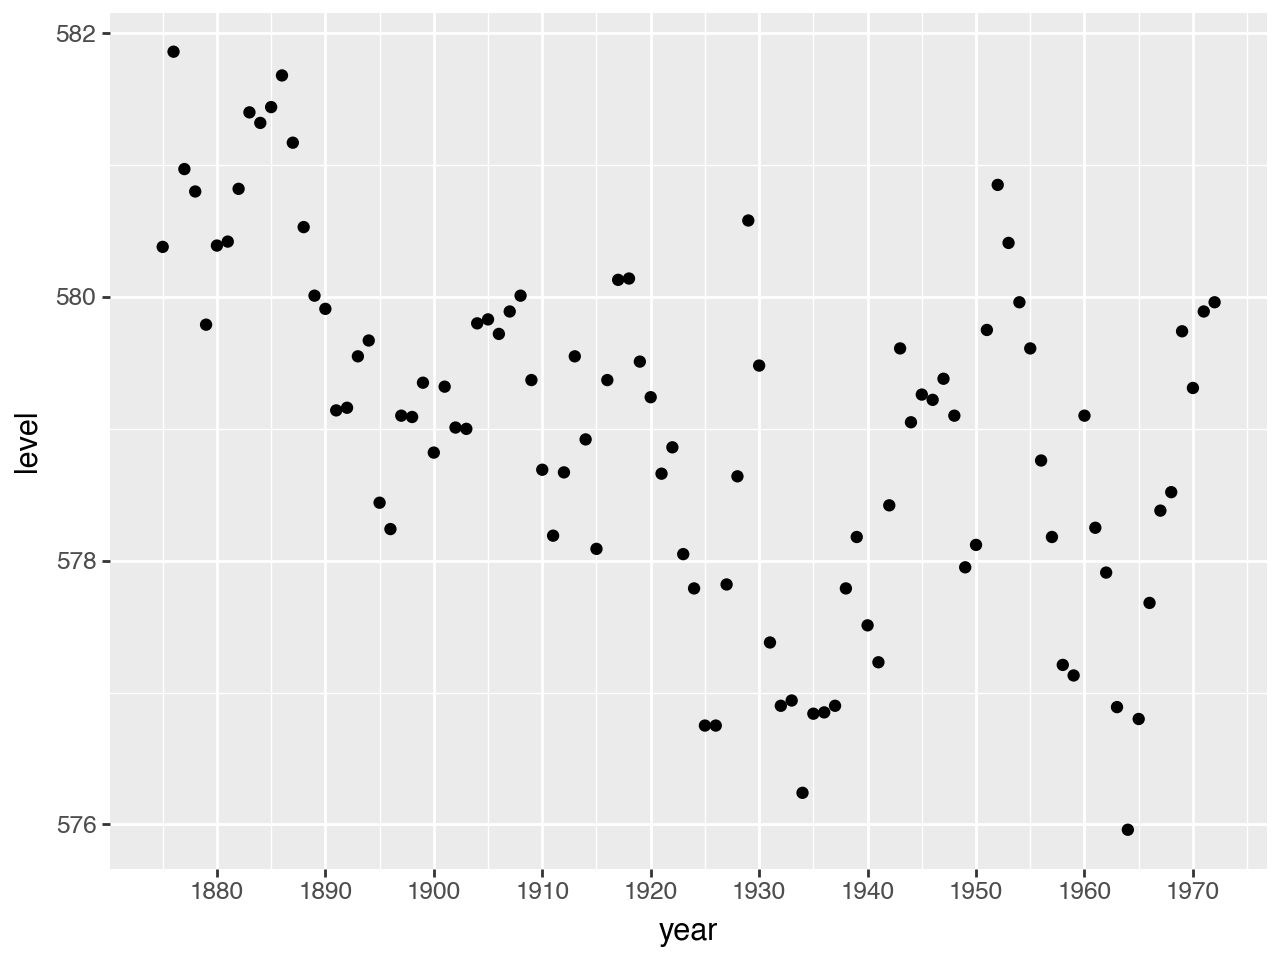

In [10]:
#you can use the scale parameter for things such as custom tick marks
p=(
    ggplot(huron, aes("year", "level"))
    + geom_point()
    + scale_x_continuous(breaks=(1870, 1880, 1890, 1900, 1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980)))


(p)

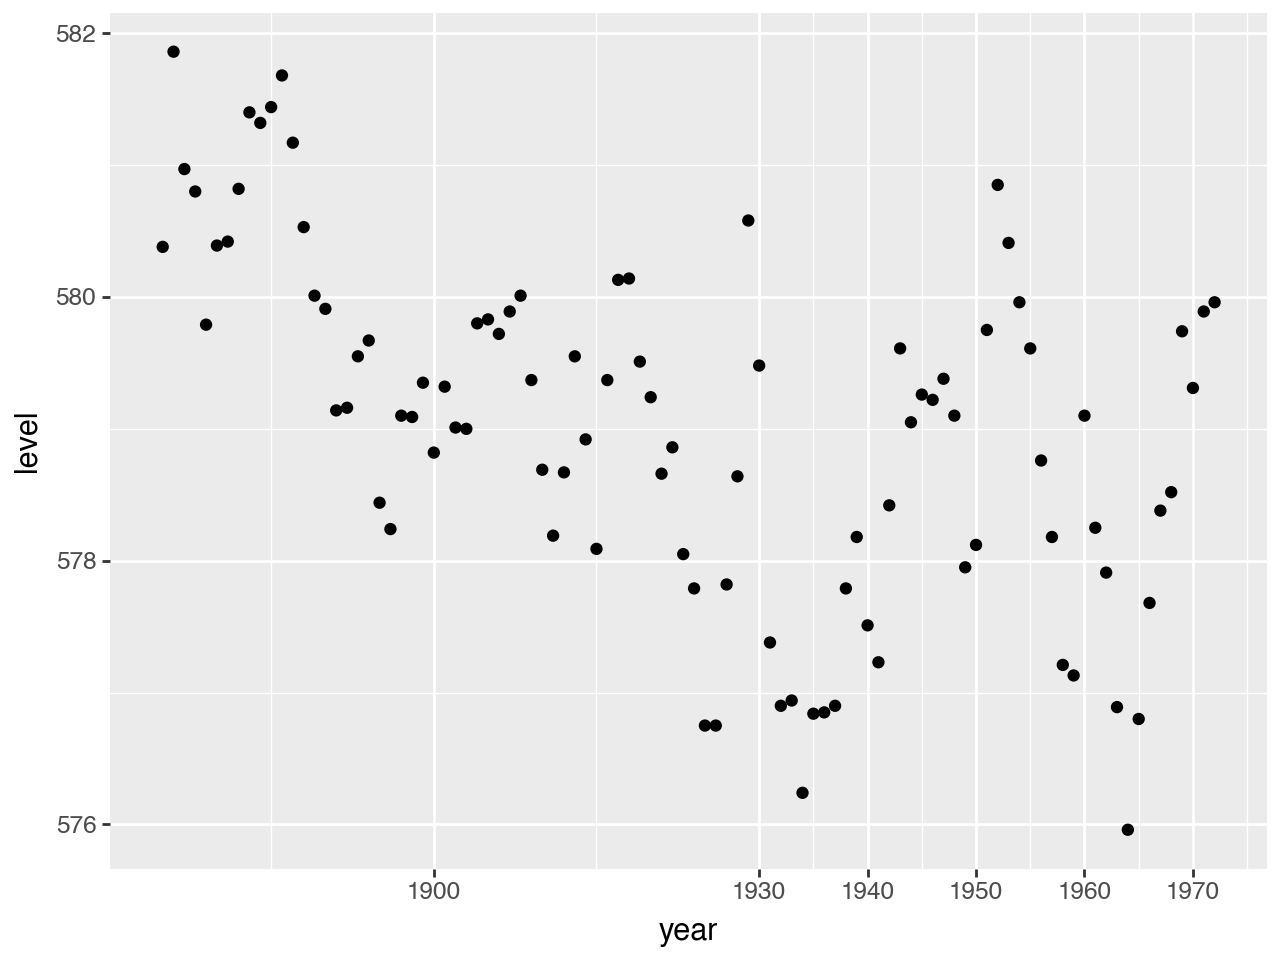

In [11]:
p=(
    ggplot(huron, aes("year", "level"))
    + geom_point()
    + scale_x_continuous(breaks=(1870, 1900, 1930, 1940, 1950, 1960, 1970, 1980)))


(p)

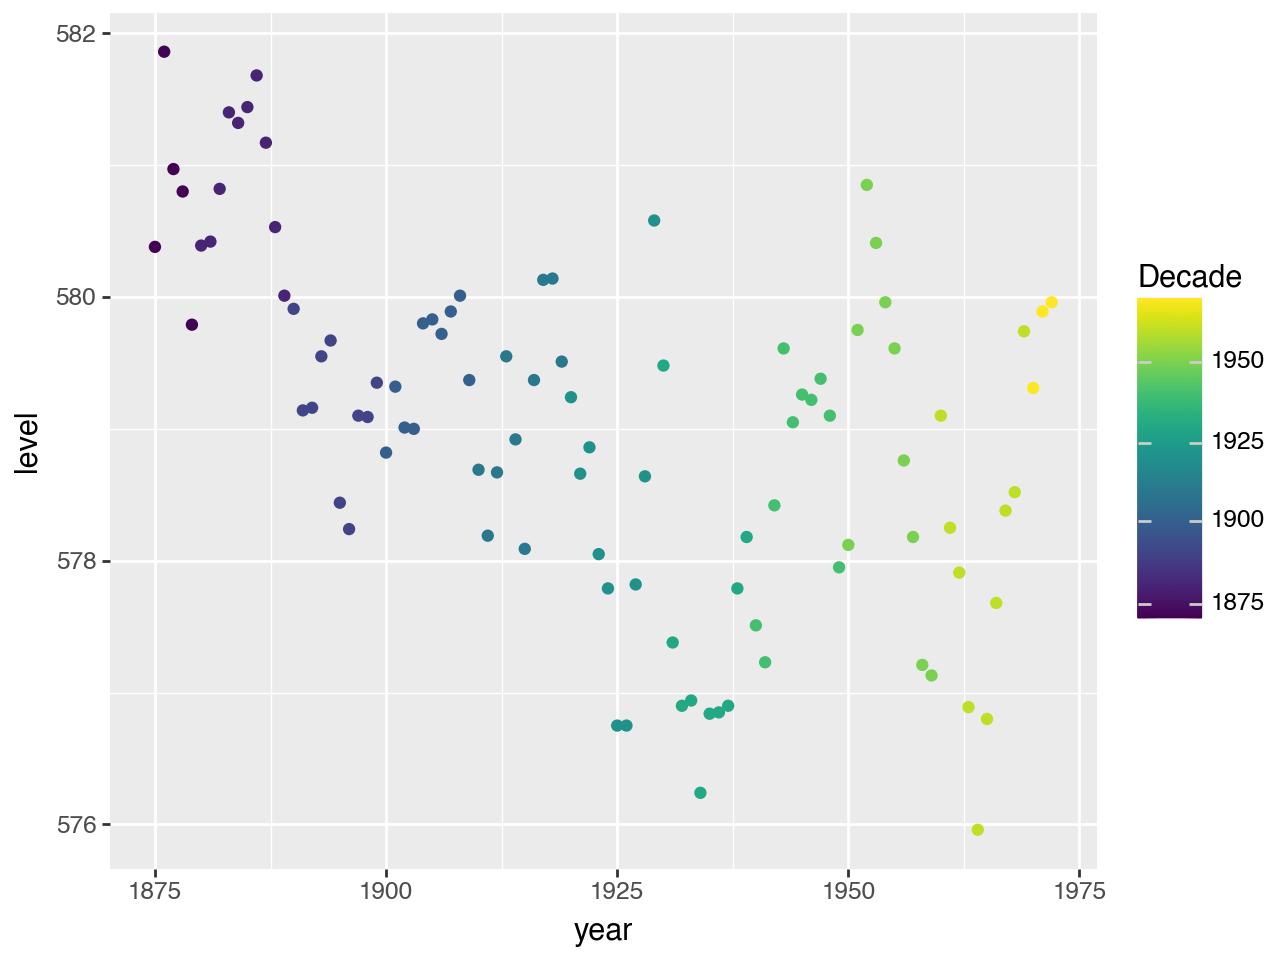

In [13]:
#you can also use scale to apply color based on a third variable as well as a legend.
p=(
    ggplot(huron, aes("year", "level", color="decade"))
    + geom_point()
    + scale_color_continuous(name='Decade', cmap_name="viridis"))


(p)

# More ggplot Parameters
- `position` - This is used to adjust the positioning of elements on the plot such as adding random jitter to ensure points don't overlap.
- `facet` - This allows us to split a plot into multiple subplots.
- `labs` - This is one way we can set labels.
- `coord` - This allows us to specify the coordinate system of the plot (such as swapping to polar using coord_polar() and also can set x and y limits.
- `theme` - Applies a pre-set theme to the plot that sets aspects such as color, legend placement, and size of text.

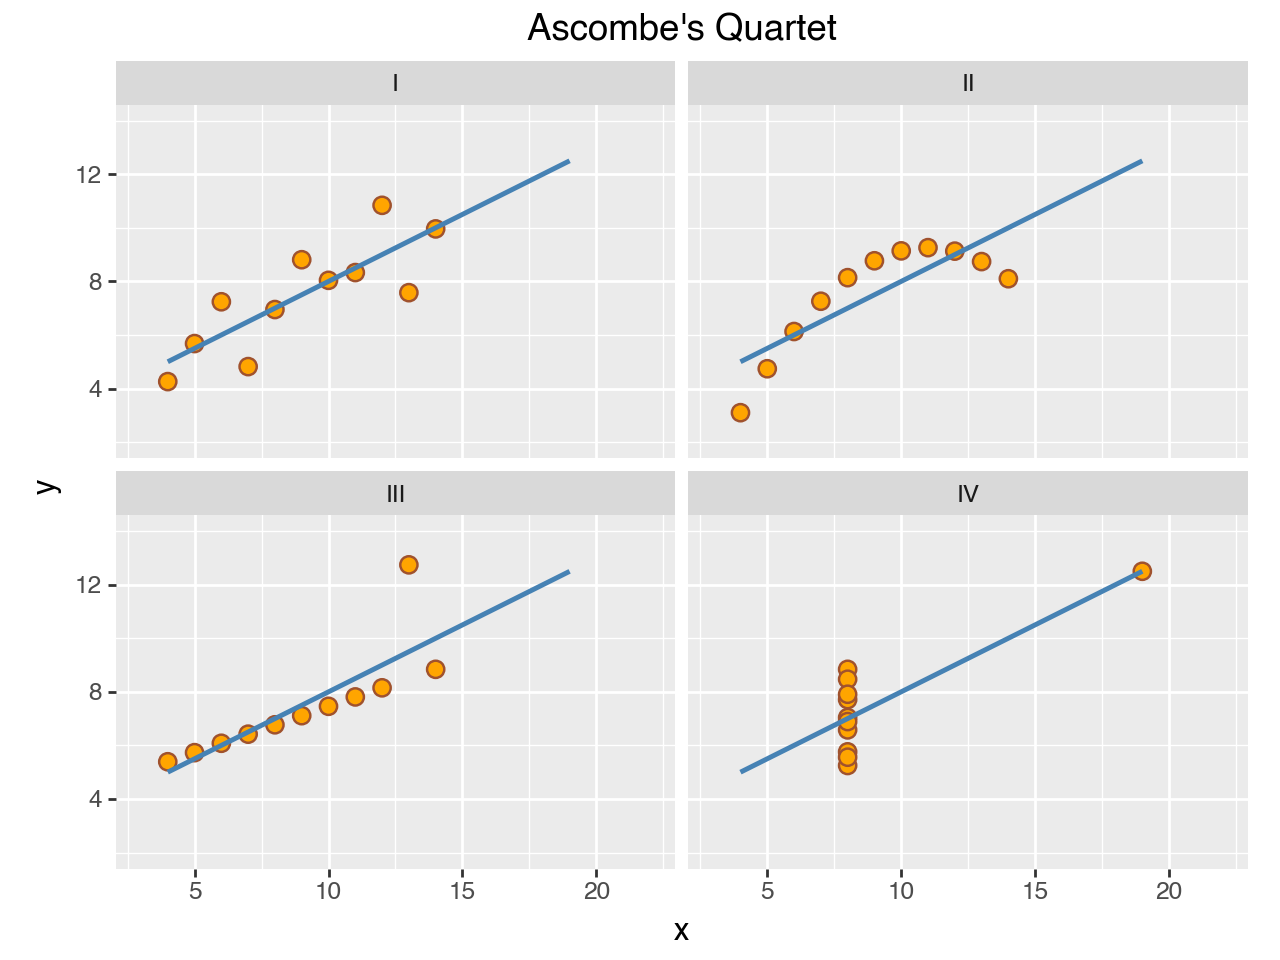

In [15]:
#making a plot with multiple subplots
p=(
    ggplot(anscombe_quartet, aes("x", "y"))
    + geom_point(color="sienna", fill="orange", size=3)
    + geom_smooth(method="lm", se=False, fullrange=True,
                  color="steelblue", size=1) #so far, all of these will apply to all sublots
    + facet_wrap("dataset") #facet_wrap is telling Plotnine to make a subplot for each different string listed in the column "dataset" in Anscombe's Quartet
    + labs(title="Ascombe's Quartet") #since we use "Title" here, the label is set as the title. The subplots are set automatically by their value in "dataset"
    + scale_y_continuous(breaks=(4, 8, 12)) 
    + coord_fixed(xlim=(3, 22), ylim=(2, 14)) #this fixes the limits for both the shared x and y axises.
   
)

(p)

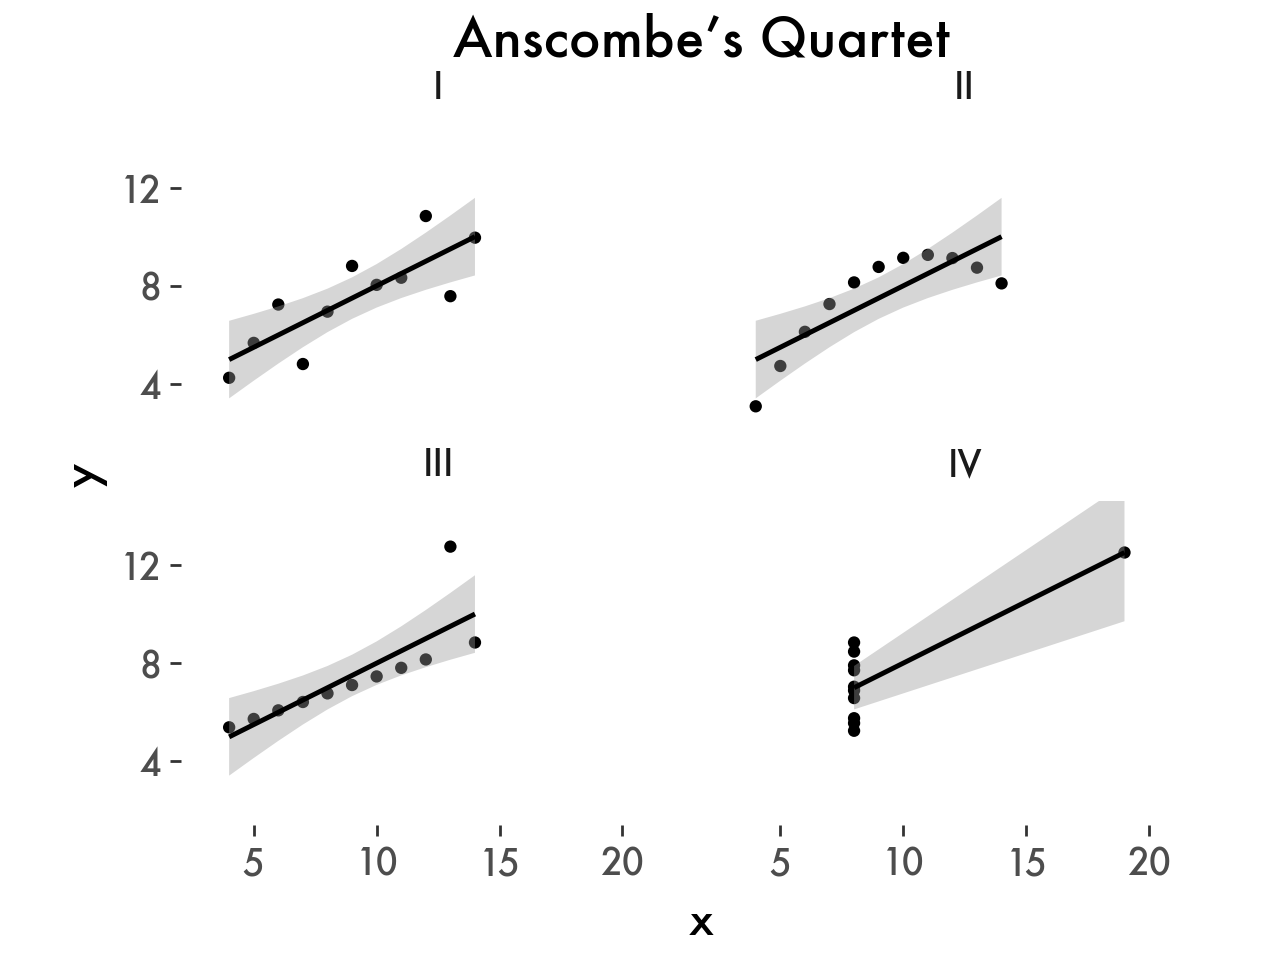

In [16]:
#now lets check out what it looks like when we apply a theme
p=(
    ggplot(anscombe_quartet, aes("x", "y"))
    + geom_point()
    + geom_smooth(method="lm") 
    + facet_wrap("dataset") 
    + labs(title="Anscombe’s Quartet") 
    + scale_y_continuous(breaks=(4, 8, 12)) 
    + coord_fixed(xlim=(3, 22), ylim=(2, 14)) 
    + theme_tufte(base_family="Futura", base_size=16)
   
)

(p)

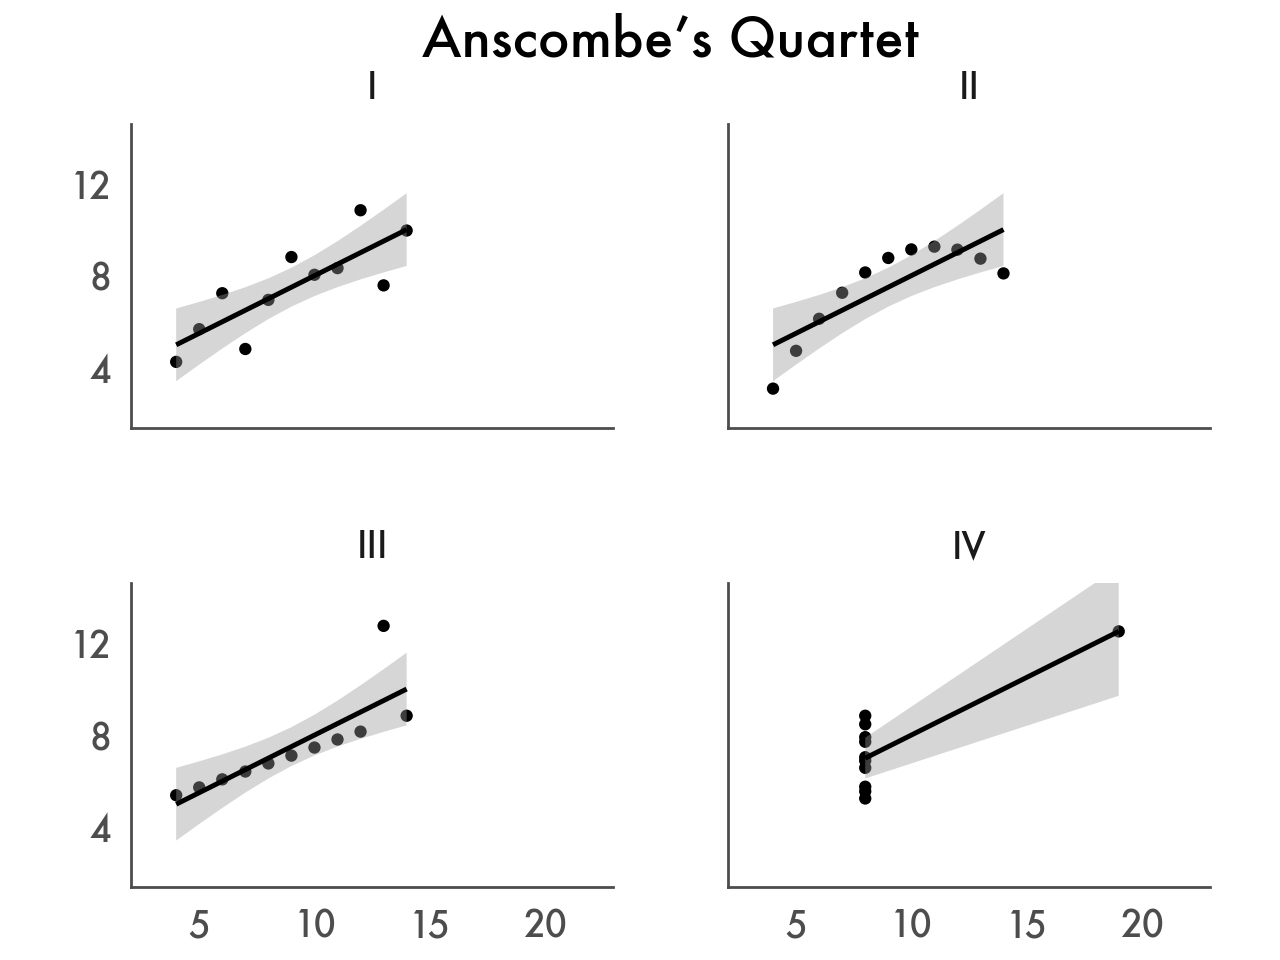

In [17]:
#you can still edit specific elements of the plot even after you've applied a theme
p=(
    ggplot(anscombe_quartet, aes("x", "y"))
    + geom_point()
    + geom_smooth(method="lm")
    + facet_wrap("dataset") 
    + labs(title="Anscombe’s Quartet") 
    + scale_y_continuous(breaks=(4, 8, 12)) 
    + coord_fixed(xlim=(3, 22), ylim=(2, 14)) 
    + theme_tufte(base_family="Futura", base_size=16) 
    + theme(
        axis_line=element_line(color="#4d4d4d"), #sets the axis lines to gray
        axis_ticks_major=element_line(color="#00000000"), #sets the tick marks to black
        axis_title=element_blank(),
        panel_spacing=0.09,
    )
)

(p)

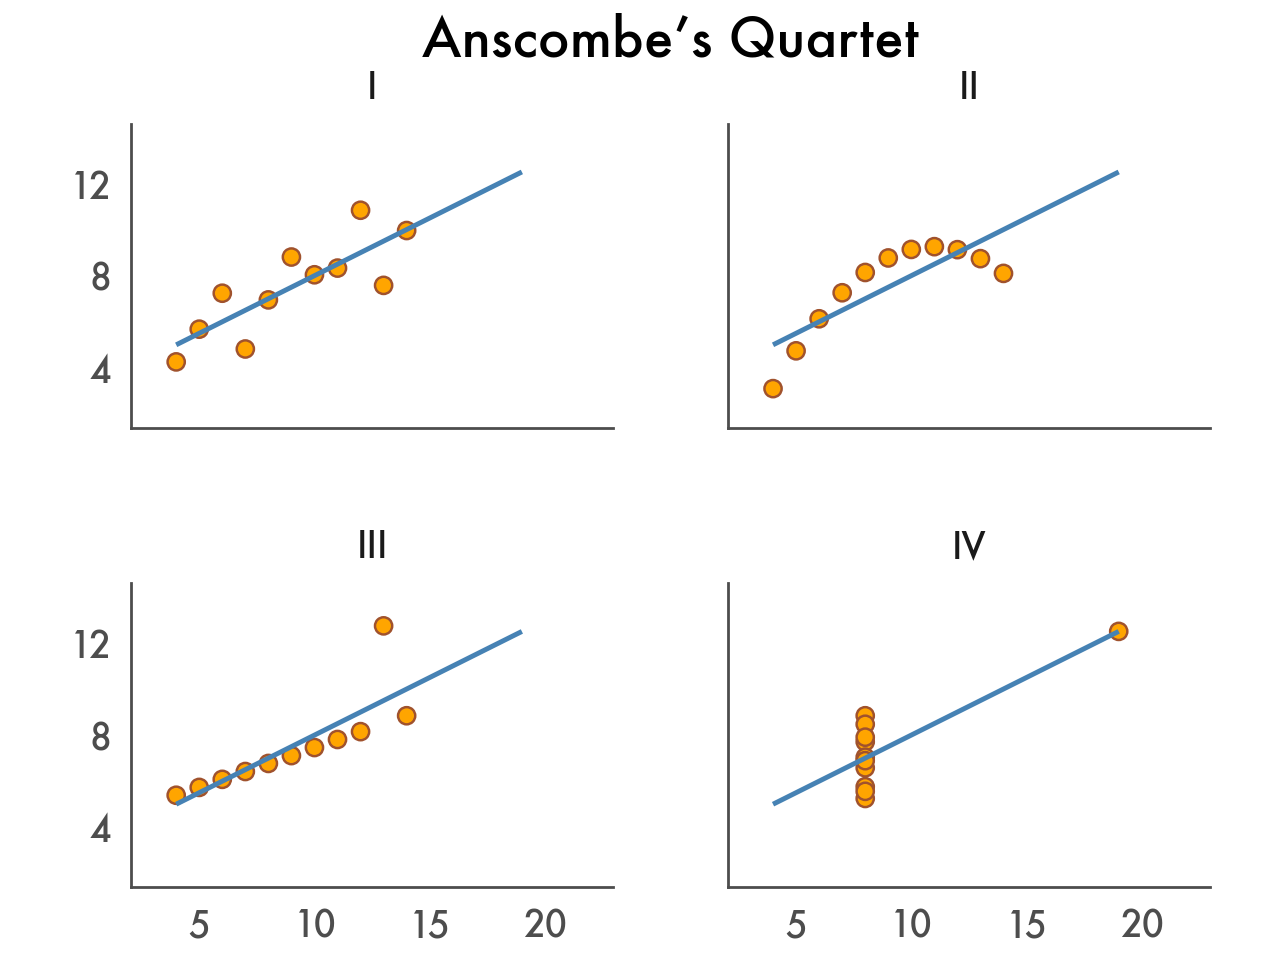

In [18]:
#you can even edit those elements up at the top in the geom parameter!
p=(
    ggplot(anscombe_quartet, aes("x", "y"))
    + geom_point(color="sienna", fill="orange", size=3)
    + geom_smooth(method="lm", se=False, fullrange=True,
                  color="steelblue", size=1) 
    + facet_wrap("dataset") 
    + labs(title="Anscombe’s Quartet") 
    + scale_y_continuous(breaks=(4, 8, 12)) 
    + coord_fixed(xlim=(3, 22), ylim=(2, 14)) 
    + theme_tufte(base_family="Futura", base_size=16) 
    + theme(
        axis_line=element_line(color="#4d4d4d"), 
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.09,
    )
)

(p)

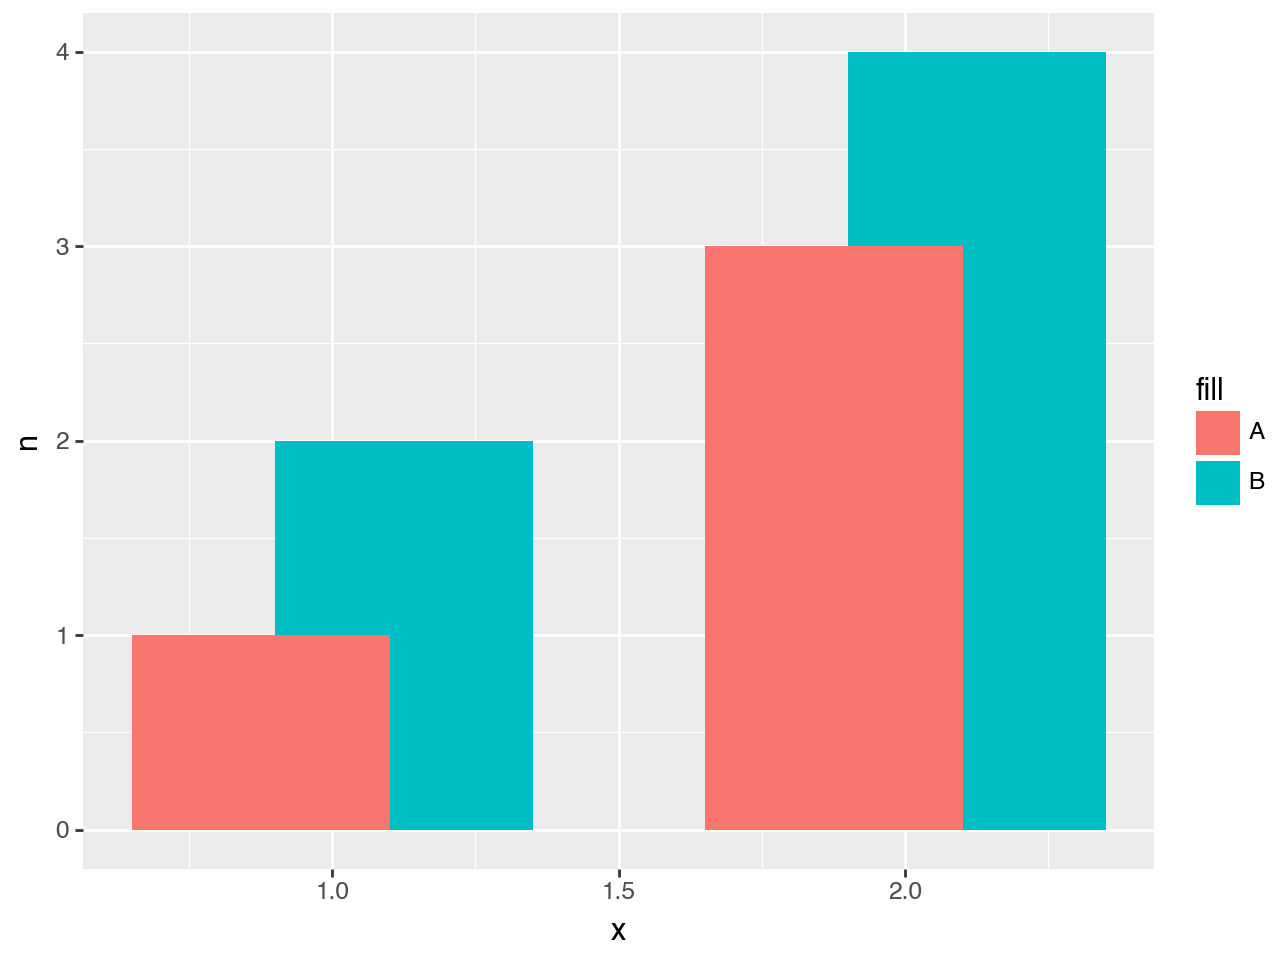

In [19]:
#you can also manipulate elements on your plot by using position
import pandas as pd

df = pd.DataFrame({"x": [1, 1, 2, 2], "n": [1, 2, 3, 4], "fill": ["A", "B"] * 2})

p1 = ggplot(df, aes("x", "n", fill="fill")) + geom_col(position=position_dodge(width=0.5))

(p1)

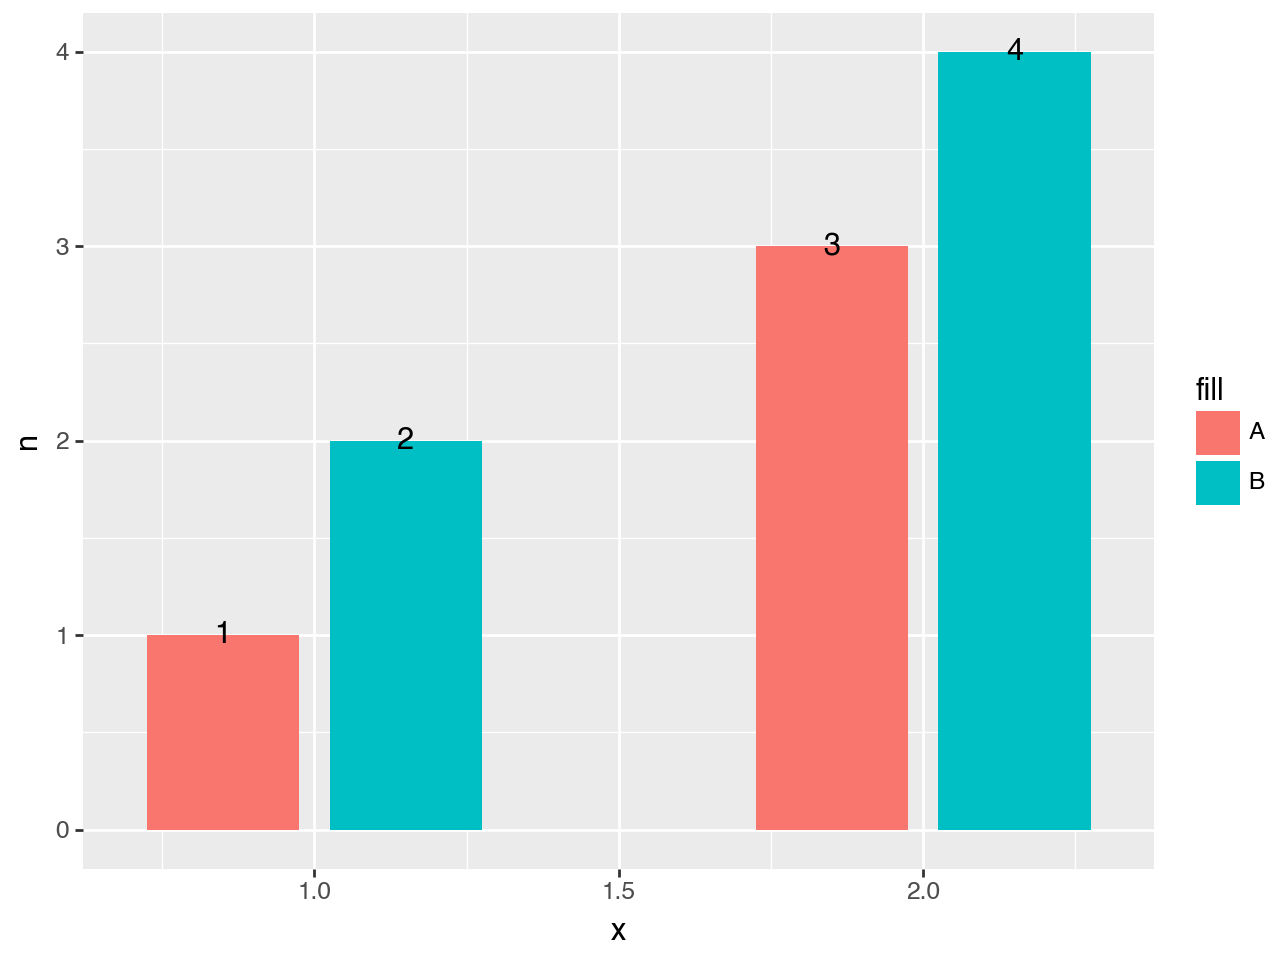

In [20]:
#then you can add dodge to make sure the columns don't overlap
dodge = position_dodge(width=0.6)#dodge moves bars side by side
p2 = (
    ggplot(df, aes("x", "n", fill="fill", label="n"))
    + geom_col(position=dodge, width=0.5)
    + geom_text(position=dodge)
)
(p2)

# BUT WAIT THERE'S MORE

You can also modify Plotnine plots using Matplotlib!

/Users/evijonas/python/archyviz/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 2 rows containing missing values.
/Users/evijonas/python/archyviz/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 2 rows containing missing values.


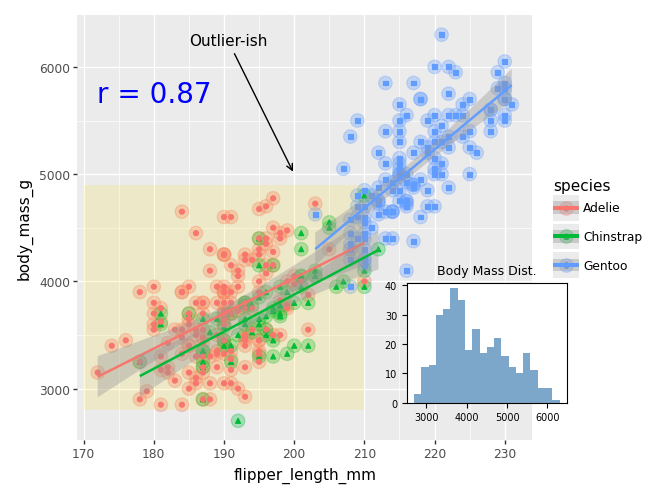

In [22]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline 
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms
from matplotlib.patches import Circle, Rectangle, FancyBboxPatch, Ellipse
from matplotlib.lines import Line2D

from plotnine.data import penguins

#generating r coeficient for the plots (overall for all penquins)
r_coef = penguins["flipper_length_mm"].corr(penguins["body_mass_g"])

p1=(#composition functionality
    ggplot(penguins, aes(x="flipper_length_mm"
                         #or:
                         #x="bill_length_mm / bill_depth_mm"#
                         , y="body_mass_g"
                         , color="species"#color automatically creates groups
                                                                #groups="species for same effect sans color
                                                                #applies to all geoms
                        ))
    + geom_point(size=5, alpha=.3,)#literal mapphings, passing value directly to geom
    + geom_point(aes(shape="species"))           # shape points
    + geom_smooth(method="lm")
    + annotate(#add r coefficient as annotations
    "text",
    x=180,
    y=5750,
    label=f"r = {r_coef:.2f}",
    color="blue",
    size=20,
    )
)

fig=p1.draw()


#add highlight
from matplotlib.patches import Rectangle

ax = fig.axes[0]
ax.add_patch(Rectangle((170, 2800), 40, 2100,
                       facecolor="gold", alpha=0.15, edgecolor="none"))

#add annotations(not appaering?)
ax.annotate(
    "Outlier-ish",
    xy=(200, 5000),        # <-- pick a point in your data range
    xytext=(185, 6200),    # <-- where the label goes
   arrowprops=dict(arrowstyle="->", lw=1),
    fontsize=11
)
#inset axes
# Get the main axes position (so we anchor relative to it)
bbox = ax.get_position()

# Create a new axes in figure coordinates
ax_hist = fig.add_axes([
    bbox.x1 - 0.38 ,   # move left from right edge of main plot
    bbox.y1 - 0.82 ,   # move down from top
    0.25,             # width
    0.25              # height
])

# Plot histogram
ax_hist.hist(
    penguins["body_mass_g"].dropna(),
    bins=20,
    color="steelblue",
    alpha=0.7
)

ax_hist.set_title("Body Mass Dist.", fontsize=9)
ax_hist.tick_params(labelsize=7)


fig

## Why Plotnine?

* Plotting with ggplot is easy, fast, and uses common plotting language and a layered plot.
* Code made in other programs, such as R, are easier to copy into matplotlib because they share a similar language.
* You can still use matplotlib to add features such as artists, texts, and other plots on top of your Plotnine plot.

## Who is Plotnine For?

* Plotnine is most useful for people working with other data visualization tools such as R or Tableau that use the Grammar of Graphics .
* Also useful for people that want to plot quickly to explore their data.

## Pros
* Simplified and fast plotting.
* Plotting languaged used for data visualization shared with other programs.
* Can edit Plotnine plots by extracting them to Matplotlib to add Matplotlib elements not native to Plotnine

## Cons
* Less overall customizability compared to Matplotlib.
* If used with Matplotlib by extracting it you have a double dependency.

# Conclusion
Plotnine is great to quickly and easily visualize exploratory data. Grammar of Graphics is well known and established meaning that there is ample documentation and the package is very stable. The main drawback is that it does not innately have as much flexibility as Matplotlib.

# Rating 
Overall: ★★★★☆

Documentation: ★★★★★

Ease of Use: ★★★★★

Flexibility: ★★☆☆☆

Maturity: ★★★★★

